# Sarsa 网格世界寻宝

基于 matplotlib 的现代实现，替代原 tkinter 版本。

**环境**: 5×5 网格，7 个陷阱（黑色），1 个宝藏（黄色），智能体（红色）从左上角出发。

**算法**: Sarsa (on-policy TD control)，使用 ε-贪心策略采样轨迹，
每个时间步更新状态-行为值函数 Q(s,a)。

In [2]:
import pandas as pd
import numpy as np
%matplotlib inline

from ReferenceCodes.Maze.d_maze import MazeEnv

In [3]:
class RL():
    def __init__(self, action_space,
                 learning_rate=0.01,
                 reward_decay=0.9,
                 e_greedy=0.9):

        self.actions = action_space
        self.lr = learning_rate
        self.gamma = reward_decay
        self.epsilon = e_greedy
        self.q_table = pd.DataFrame(columns=self.actions, dtype=np.float64)

    def check_state_exist(self, state):
        if state not in self.q_table.index:
            new_row = pd.DataFrame(
                [[0.0] * len(self.actions)],
                columns=self.q_table.columns,
                index=[state]
            )
            self.q_table = pd.concat([self.q_table, new_row])

    def choose_action(self, observation):
        self.check_state_exist(observation)
        if np.random.rand() < self.epsilon:
            # 贪婪：选择最优行为 (随机打破平局)
            state_action = self.q_table.loc[observation, :]
            max_val = state_action.max()
            best_actions = state_action[state_action == max_val].index.tolist()
            action = np.random.choice(best_actions)
        else:
            # 探索：随机选择
            action = np.random.choice(self.actions)
        return action

    def learn(self, *args):
        pass

In [4]:
# 在线策略 Sarsa
class SarsaTable(RL):
    def __init__(self, actions,
                 learning_rate=0.01,
                 reward_decay=0.9,
                 e_greedy=0.9):
        super().__init__(actions, learning_rate, reward_decay, e_greedy)

    def learn(self, s, a, r, s_, a_):
        self.check_state_exist(s)
        q_predict = self.q_table.loc[s, a]

        if s_ != 'terminal':
            q_target = r + self.gamma * self.q_table.loc[s_, a_]
        else:
            q_target = r

        # Q(s,a) ← Q(s,a) + α·[r + γ·Q(s',a') − Q(s,a)]
        self.q_table.loc[s, a] += self.lr * (q_target - q_predict)

    def get_action(self, q_table, state):
        state_action = q_table.loc[state, :]
        max_val = state_action.max()
        idxs = [i for i, v in enumerate(state_action) if v == max_val]
        idxs.sort()
        return tuple(idxs)

    def get_policy(self, q_table, env, rows=5, cols=5, pixels=40, origin=20):
        policy = []
        trap_centers = env.trap_centers
        treasure_center = env.treasure_center

        for i in range(rows):
            for j in range(cols):
                cx = j * pixels + origin
                cy = i * pixels + origin
                center = np.array([cx, cy])

                # 检查是否为陷阱或宝藏
                if (np.array_equal(center, treasure_center) or
                    any(np.array_equal(center, tc) for tc in trap_centers)):
                    policy.append(-1)
                    continue

                item_state = [cx - 15.0, cy - 15.0, cx + 15.0, cy + 15.0]
                if str(item_state) not in q_table.index:
                    policy.append((0, 1, 2, 3))
                    continue

                policy.append(self.get_action(q_table, str(item_state)))
        return policy

In [5]:
def update(agent, env, episodes=50):
    """Sarsa 训练主循环"""
    for episode in range(episodes):
        observation = env.reset()
        while True:
            env.render()

            action = agent.choose_action(str(observation))
            next_obs, reward, done, oval_flag = env.step(action)
            next_action = agent.choose_action(str(next_obs))

            # Sarsa 更新: (s, a, r, s', a')
            agent.learn(str(observation), action, reward,
                       str(next_obs), next_action)

            observation = next_obs
            if done:
                break

        if (episode + 1) % 10 == 0:
            print(f'第 {episode + 1} 局结束')

    # 提取策略并可视化
    policy = agent.get_policy(agent.q_table, env)
    policy_grid = np.array(policy, dtype=object).reshape(5, 5)

    env.render_by_policy(policy_grid)

    print('\n最终 Q 表:')
    print(agent.q_table)
    print('\n最优策略 (0:↑ 1:↓ 2:← 3:→,  -1:障碍/宝藏):')
    print(policy_grid)

    return policy_grid

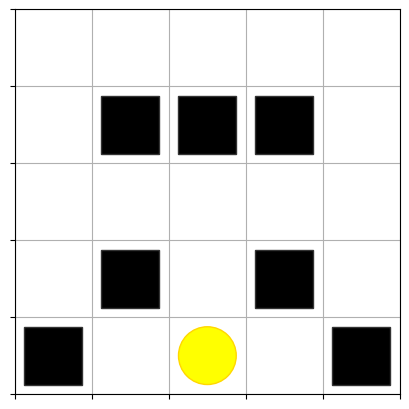

In [ ]:
env = MazeEnv()
agent = SarsaTable(actions=list(range(env.n_actions)))
policy = update(agent, env, episodes=50)